In [1]:
#Basic libraries
import numpy as np
import pandas as pd

#Visualization Libraries
import matplotlib.pyplot as plt
import pydot
import seaborn as sns

#Evaluation Libraries
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV

#Deep Learning Libraries
import tensorflow as tf
from tensorflow.keras import layers
import keras
from keras.models import Sequential
from keras.layers import Dense, Activation, Dropout, Flatten
# from keras.layers.core import Dense,Activation,Dropout
from keras.datasets import mnist
from keras import utils as np_utils
from keras.utils import to_categorical
from scikeras.wrappers import KerasClassifier
# from keras.wrappers.scikit_learn import KerasClassifier


In [3]:
fashion_train = pd.read_csv("fashion-mnist_train.csv")
fashion_test = pd.read_csv("fashion-mnist_test.csv")

In [4]:
fashion_train.shape

(60000, 785)

In [5]:
fashion_test.shape

(10000, 785)

In [6]:
X_train_fashion = fashion_train.drop('label',axis=1)
y_train_fashion = fashion_train['label']
X_test_fashion = fashion_test.drop('label',axis=1)
y_test_fashion = fashion_test['label']

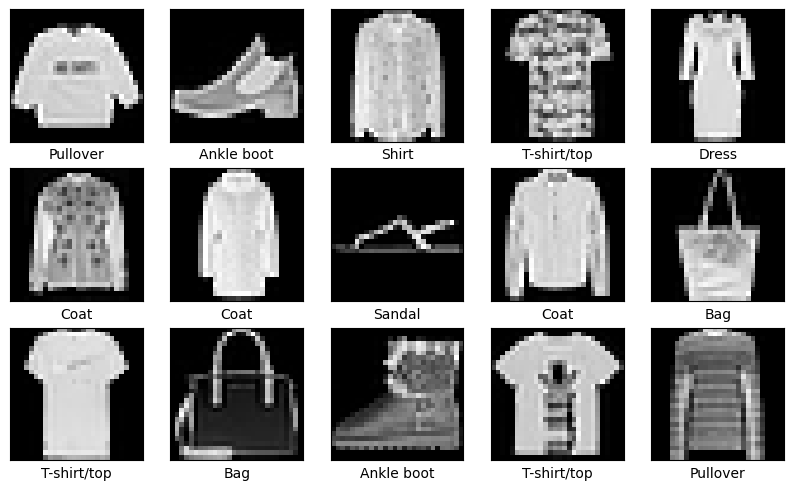

In [10]:
#reshaping the dataset
X_train_reshape = X_train_fashion.values.reshape(-1,28,28)
X_test_reshape = X_test_fashion.values.reshape(-1,28,28)

col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#visulaize the digits
plt.figure(figsize=(10,10))
for i in range(15):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(X_train_reshape[i],cmap ='gray')
    plt.xlabel(col_names[y_train_fashion[i]])
plt.show()

In [11]:
#convert the oneD to categorial - Encoding digit mnist labels - output should be One hot encoding for ANN
y_train_fashion = to_categorical(y_train_fashion,num_classes = 10)
y_test_fashion = to_categorical(y_test_fashion,num_classes = 10)

In [12]:
#ANN and CNN are sequential process I/P - hiden layer - O/P
# Feedforward
model = keras.Sequential([
    layers.Dense(128,activation = 'relu',input_shape=(784,),), #Input layer
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24,activation = 'relu'), # first hidden layer
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(24,activation = 'relu'), # second hidden layer
    layers.Dropout(0.3),
    layers.BatchNormalization(),
    layers.Dense(10,activation = 'softmax'),# output layer - one to 10 categories
])
#compiling the model - https://keras.io/api/
model.compile(loss = "categorical_crossentropy",
            optimizer = "adam",
             metrics=['accuracy'])

history = model.fit(X_train_fashion,y_train_fashion,batch_size = 100,epochs = 30,validation_data = (X_test_fashion,y_test_fashion) )

C:\Users\SAIRAM\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.6265 - loss: 1.1019 - val_accuracy: 0.8245 - val_loss: 0.5447
Epoch 2/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7522 - loss: 0.7399 - val_accuracy: 0.8260 - val_loss: 0.4963
Epoch 3/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7751 - loss: 0.6740 - val_accuracy: 0.8435 - val_loss: 0.4532
Epoch 4/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7911 - loss: 0.6355 - val_accuracy: 0.8425 - val_loss: 0.4541
Epoch 5/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.7981 - loss: 0.6103 - val_accuracy: 0.8601 - val_loss: 0.4152
Epoch 6/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8026 - loss: 0.5994 - val_accuracy: 0.8593 - val_loss: 0.4128
Epoch 7/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8065 - loss: 0.5857 - val_accuracy: 0.8424 - val_loss: 0.4406
Epoch 8/30
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8084 - loss: 0.5741 - val_accuracy: 0.

In [17]:
#to test
y_predict = model.predict(X_test_fashion)
y_predicts = np.argmax(y_predict,axis = 1)
y_test_fashion_eval = np.argmax(y_test_fashion,axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


[[884   0   8  49   1   0  44   0  14   0]
 [  4 973   0  19   2   1   1   0   0   0]
 [ 23   0 733  17 149   0  73   0   5   0]
 [ 22   7   2 944  13   0  10   0   2   0]
 [  1   1  49  43 841   0  62   0   3   0]
 [  0   0   0   0   0 915   1  54   3  27]
 [227   3  80  38  83   0 554   0  15   0]
 [  0   0   0   0   0  17   0 955   0  28]
 [  4   0   3   3   3   3   9   4 970   1]
 [  0   0   0   0   0   6   0  49   0 945]]


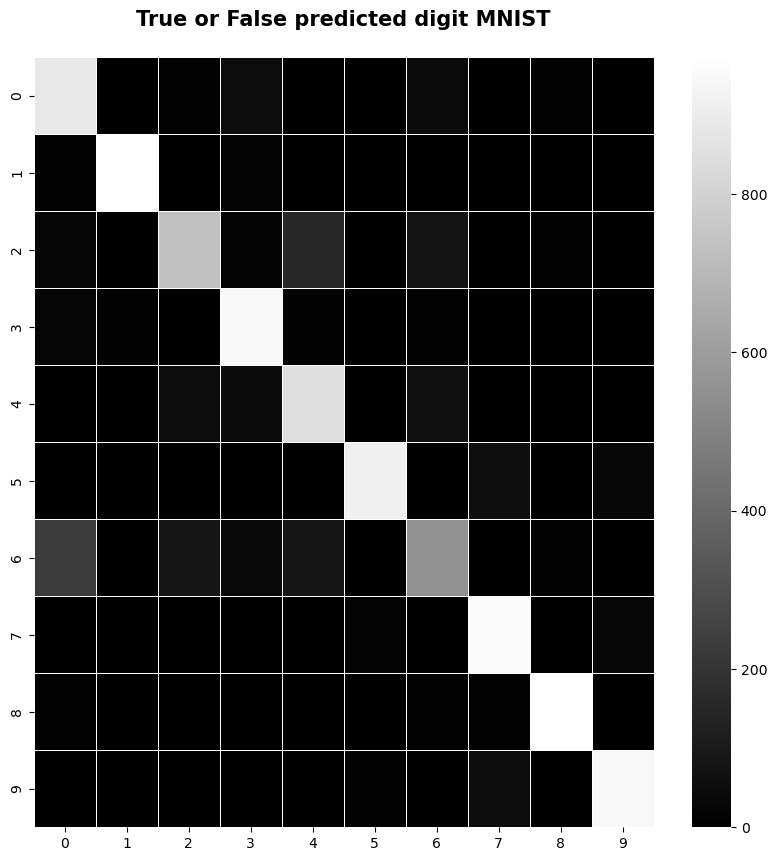

In [18]:
#confusion matrix for Digit Mnist
con_mat = confusion_matrix(y_test_fashion_eval,y_predicts)
print(con_mat)
# plt.style.use('seaborn-v0_8-deep')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot_kws={'size':15},linewidth=0.5,fmt ='d',cmap ='grey')
plt.title('True or False predicted digit MNIST\n',fontweight='bold',fontsize=15)
plt.show()

In [19]:
from sklearn.metrics import classification_report
report = classification_report(y_test_fashion_eval,y_predicts)

In [20]:
print(report)

              precision    recall  f1-score   support

           0       0.76      0.88      0.82      1000
           1       0.99      0.97      0.98      1000
           2       0.84      0.73      0.78      1000
           3       0.85      0.94      0.89      1000
           4       0.77      0.84      0.80      1000
           5       0.97      0.92      0.94      1000
           6       0.73      0.55      0.63      1000
           7       0.90      0.95      0.93      1000
           8       0.96      0.97      0.96      1000
           9       0.94      0.94      0.94      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



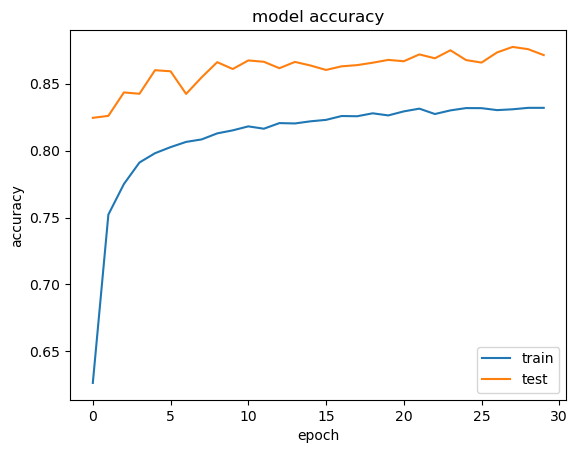

In [21]:
#summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc = 'best')
plt.show()

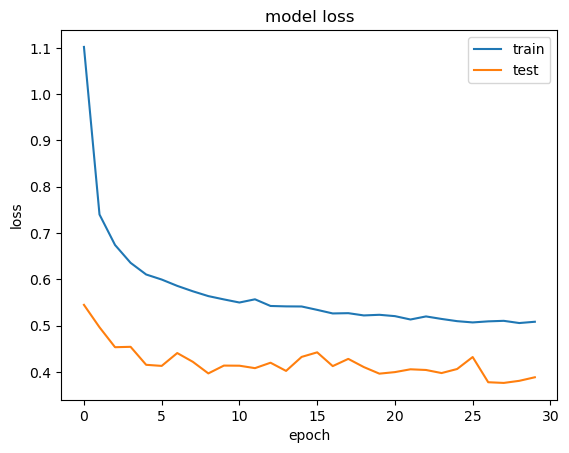

In [22]:
#summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc = 'best')
plt.show()

In [34]:
y_predict_single = model.predict(X_test_fashion.loc[[2],:].values)
print(y_predict_single)
y_predicts_single = np.argmax(y_predict_single,axis=1)
print(y_predicts_single)
y_test_digit_eval = np.argmax(y_test_fashion,axis =1)
print(y_test_digit_eval)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[1.24231279e-02 2.54861952e-04 5.45490086e-01 4.24603513e-03
  1.11671634e-01 2.56974192e-04 3.20820063e-01 1.53683533e-04
  4.40465286e-03 2.78817024e-04]]
[2]
[0 1 2 ... 8 8 1]


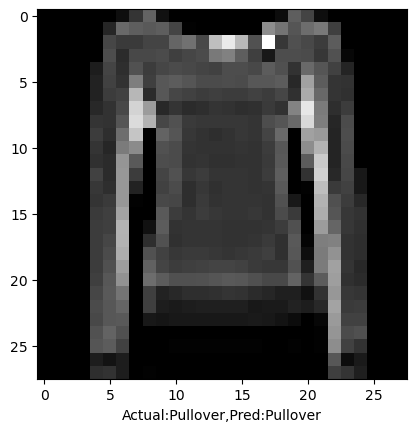

In [35]:
col_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat','Sandal','Shirt','Sneaker','Bag','Ankle boot']

#visulaize the digits
plt.imshow(X_test_reshape[2],cmap ='gray')
plt.xlabel("Actual:{},Pred:{}".format(col_names[y_test_digit_eval[2]],col_names[y_predicts_single[0]]))
plt.show()